# Sankung Fatty 

Build a classifier to predict the Target column using the other 20 features. 


When you split your data into training and test sets, set random_state = 5. (2 points)


Try a random forest (use random_state = 5 and 400 trees), a boosting classifier (use n_estimators = 300, learning rate =0.1, and max_depth =3), and a logistic regression classifier. (9 points: 3 for each classifier)


Which is best? How can you tell? (6 points)


Comment on the precision, recall, and accuracy of your model. (3 points)



In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report


In [2]:
from sklearn.model_selection import cross_validate
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn import datasets
from sklearn.metrics import accuracy_score
from sklearn import tree
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.linear_model import LogisticRegression

In [4]:
df = pd.read_csv("/Users/Sankung/Desktop/MSDS/classify_imb.csv")
df.head()

,A,B,C,D,E,F,G,H,I,J,...,L,M,N,O,P,Q,R,S,T,Target
0,2.868690,-0.106937,1.065444,0.749917,2.138981,-0.267874,-4.287288,-0.003229,0.102618,-1.594098,...,-0.031744,-1.836612,2.508588,2.123112,-1.599241,0.944821,0.330276,1.017247,-0.440207,0
1,-1.463642,-1.291157,-1.464761,1.287344,-1.994637,0.831797,0.130555,-0.555585,-1.746450,0.320191,...,-0.948864,0.497305,2.651037,1.722998,0.290210,-1.278545,0.488835,1.577497,-1.097335,1
2,-2.208983,1.112905,1.484842,1.455104,-0.380712,-0.465900,3.464477,1.561576,-0.972615,2.646365,...,0.571619,-0.573899,-4.393691,-3.936344,5.499447,0.874778,-0.858103,-1.040617,-2.759917,0
3,1.757493,-0.194035,-1.502209,-1.227620,-1.629453,2.192913,-0.774430,-1.284792,0.433154,2.233775,...,0.089484,-2.290146,-2.274138,-3.454273,-0.904307,0.459121,-0.043155,-2.129675,-0.559314,0
4,-0.621503,-1.709654,-2.155096,-1.982270,-1.205284,-0.285097,-1.279000,-3.831940,-1.205034,-4.213100,...,0.808936,0.647993,4.629954,3.860843,-1.288296,0.992935,1.069965,3.676966,1.005724,0


In [5]:
len(df)

1000

In [7]:
df['Target'].sum()/len(df)

0.321

<AxesSubplot:>

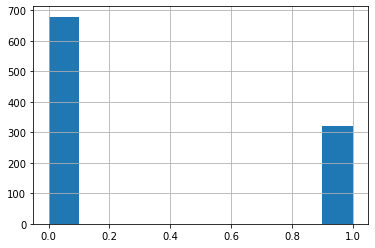

In [8]:
df.Target.hist()

In [9]:
X=df.drop('Target',axis=1)
y=df['Target']

In [10]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.3, random_state=5)

In [11]:
print(sum(y_train)/len(y_train),":",sum(y_test)/len(y_test))

0.3157142857142857 : 0.3333333333333333


The training and test sets reflect the overall percentage of class one observations

In [13]:
# Scale the data
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Random Forest

In [14]:

# Random forest classifier
rfc = RandomForestClassifier(n_estimators=400, random_state=5)
rfc.fit(X_train, y_train)
rfc_pred = rfc.predict(X_test)
rfc_acc = accuracy_score(y_test, rfc_pred)
print('Random Forest Classifier Accuracy:', rfc_acc)

Random Forest Classifier Accuracy: 0.7766666666666666


In [22]:
print(classification_report(y_test,rfc_pred))

              precision    recall  f1-score   support

           0       0.77      0.95      0.85       200
           1       0.81      0.43      0.56       100

    accuracy                           0.78       300
   macro avg       0.79      0.69      0.71       300
weighted avg       0.78      0.78      0.75       300



# Gradient boosting classifier

In [15]:
# Gradient boosting classifier
gbc = GradientBoostingClassifier(n_estimators=300, learning_rate=0.1, max_depth=3, random_state=5)
gbc.fit(X_train, y_train)
gbc_pred = gbc.predict(X_test)
gbc_acc = accuracy_score(y_test, gbc_pred)
print('Gradient Boosting Classifier Accuracy:', gbc_acc)

Gradient Boosting Classifier Accuracy: 0.7566666666666667


In [21]:
print(classification_report(y_test,gbc_pred))

              precision    recall  f1-score   support

           0       0.77      0.91      0.83       200
           1       0.71      0.46      0.56       100

    accuracy                           0.76       300
   macro avg       0.74      0.68      0.69       300
weighted avg       0.75      0.76      0.74       300



# Logistic regression classifier

In [16]:
# Logistic regression classifier
lr = LogisticRegression(random_state=5)
lr.fit(X_train, y_train)
lr_pred = lr.predict(X_test)
lr_acc = accuracy_score(y_test, lr_pred)
print('Logistic Regression Classifier Accuracy:', lr_acc)

Logistic Regression Classifier Accuracy: 0.6833333333333333


In [19]:
print(classification_report(y_test,lr_pred))

              precision    recall  f1-score   support

           0       0.69      0.97      0.80       200
           1       0.65      0.11      0.19       100

    accuracy                           0.68       300
   macro avg       0.67      0.54      0.50       300
weighted avg       0.67      0.68      0.60       300



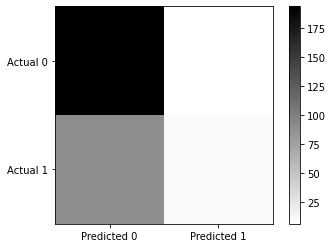

In [23]:
from sklearn.metrics import confusion_matrix


# Get the confusion matrix for the logistic regression model
cm = confusion_matrix(y_test, lr_pred)

# Plot the confusion matrix as a heatmap
plt.imshow(cm, cmap='binary', interpolation='None')
plt.colorbar()
plt.xticks([0, 1], ['Predicted 0', 'Predicted 1'])
plt.yticks([0, 1], ['Actual 0', 'Actual 1'])
plt.show()


Based on the precision and accuracy scores we analyzed, the Random Forest classifier achieved the highest overall accuracy score of 0.78. When we look at the precision scores, the Random Forest classifier achieved the highest precision for both classes, indicating that it had a better ability to correctly identify instances of both classes. Random Forest seems to be leading the race in all aspects. Let's visualize this to have a clear picture.

In [31]:
# Get the predicted probabilities for the test data
rf_prob = rfc.predict_proba(X_test)
boost_prob = gbc.predict_proba(X_test)
lr_prob = lr.predict_proba(X_test)
# Get the precision, recall, and thresholds for the random forest model
precision_rf, recall_rf, thresholds_rf = precision_recall_curve(y_test, rf_prob[:, 1])

# ROC curve

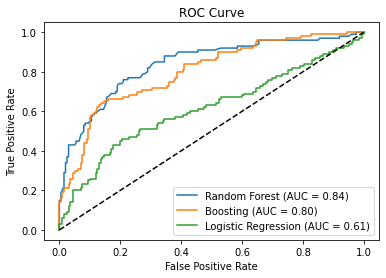

In [32]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Get the false positive rate, true positive rate, and thresholds for each model
fpr_rf, tpr_rf, thresholds_rf = roc_curve(y_test, rf_prob[:, 1])
fpr_boost, tpr_boost, thresholds_boost = roc_curve(y_test, boost_prob[:, 1])
fpr_lr, tpr_lr, thresholds_lr = roc_curve(y_test, lr_prob[:, 1])

# Calculate the AUC (Area Under Curve) for each model
auc_rf = auc(fpr_rf, tpr_rf)
auc_boost = auc(fpr_boost, tpr_boost)
auc_lr = auc(fpr_lr, tpr_lr)

# Plot the ROC curves for each model
plt.plot(fpr_rf, tpr_rf, label='Random Forest (AUC = %0.2f)' % auc_rf)
plt.plot(fpr_boost, tpr_boost, label='Boosting (AUC = %0.2f)' % auc_boost)
plt.plot(fpr_lr, tpr_lr, label='Logistic Regression (AUC = %0.2f)' % auc_lr)
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc='lower right')
plt.show()


# Precision-recall curve

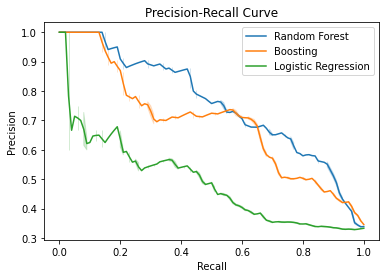

In [33]:
from sklearn.metrics import precision_recall_curve
import seaborn as sns

# Get the precision, recall, and thresholds for each model
precision_rf, recall_rf, thresholds_rf = precision_recall_curve(y_test, rf_prob[:, 1])
precision_boost, recall_boost, thresholds_boost = precision_recall_curve(y_test, boost_prob[:, 1])
precision_lr, recall_lr, thresholds_lr = precision_recall_curve(y_test, lr_prob[:, 1])

# Plot the precision-recall curves for each model
sns.lineplot(x=recall_rf, y=precision_rf, label='Random Forest')
sns.lineplot(x=recall_boost, y=precision_boost, label='Boosting')
sns.lineplot(x=recall_lr, y=precision_lr, label='Logistic Regression')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend()
plt.show()
